# Day 03：反向传播的直觉 —— 链式法则的代码实现

> ☀️ 第二周 · 破局与复兴 · 第 3 天

昨天我们有了激活函数和隐藏层，模型可以学习了。

但还有一个核心问题没解决：**输出层的误差，怎么知道该归咎于哪个隐藏神经元？**

这叫「信用分配问题」——output error 该**分摊**给谁？

**反向传播（Backpropagation）** 就是解决这个问题的算法。它的核心是**链式法则**。

**今天的任务**：不用复杂的数学公式，用代码直观理解反向传播是如何工作的。

---

## 1. 信用分配问题

想象一家公司：

```
    员工A ──┐
            ├──→ 部门经理 ──→ 总经理 ──→ 客户投诉
    员工B ──┘
```

客户投诉了（输出误差），但责任怎么分摊？

- 员工A 贡献了 30%？
- 员工B 贡献了 70%？

反向传播就是一套**公平分摊责任**的算法。

---

## 2. 链式法则的直观理解

链式法则：如果 C 依赖于 B，B 依赖于 A，那么：

∂C/∂A = ∂C/∂B × ∂B/∂A

这意味着：**A 对 C 的影响 = A 对 B 的影响 × B 对 C 的影响**

就像多米诺骨牌：
A 倒了 → B 倒了 → C 倒了
如果 B 倒的角度决定了 C 倒的速度，那么 A 通过 B 间接影响了 C。

In [1]:
import torch

# 简单例子：假设
# z = 2 * x（x 影响 z）
# y = z + 1（z 影响 y）
# 最终损失 C = (y - 3)²

x = torch.tensor(1.0, requires_grad=True)
z = 2 * x          # z = 2
y = z + 1          # y = 3
C = (y - 3)**2     # C = 0

print("Forward Pass:")
print(f"  x = {x.item()}")
print(f"  z = 2 * x = {z.item()}")
print(f"  y = z + 1 = {y.item()}")
print(f"  C = (y - 3)² = {C.item()}")

print("\nNow verify chain rule with PyTorch autograd:")
C.backward()
print(f"  ∂C/∂x = {x.grad.item()}")

print("\nManual Chain Rule Verification:")
print(f"  ∂C/∂y = 2*(y-3) = {2*(y.item()-3)}")
print(f"  ∂y/∂z = 1")
print(f"  ∂z/∂x = 2")
print(f"  ∂C/∂x = ∂C/∂y × ∂y/∂z × ∂z/∂x = {2*(y.item()-3)} × 1 × 2 = {(2*(y.item()-3) * 1 * 2)}")

Forward Pass:
  x = 1.0
  z = 2 * x = 2.0
  y = z + 1 = 3.0
  C = (y - 3)² = 0.0

Now verify chain rule with PyTorch autograd:
  ∂C/∂x = 0.0

Manual Chain Rule Verification:
  ∂C/∂y = 2*(y-3) = 0.0
  ∂y/∂z = 1
  ∂z/∂x = 2
  ∂C/∂x = ∂C/∂y × ∂y/∂z × ∂z/∂x = 0.0 × 1 × 2 = 0.0


---

## 3. 反向传播的分步实现

现在我们把链式法则应用到一个简单的一层网络中：

```
输入 x ──→ [z = x·W + b] ──→ [a = sigmoid(z)] ──→ 输出 y
                ↑                      ↑
               W, b                  激活函数
```

我们手动实现这个前向传播和反向传播。

In [2]:
def sigmoid(z):
    return 1 / (1 + torch.exp(-z))

def sigmoid_derivative(z):
    """sigmoid 导数：sigmoid(z) * (1 - sigmoid(z))"""
    s = sigmoid(z)
    return s * (1 - s)

class SimpleNeuron:
    """
    简单神经元：支持手动前向传播和反向传播
    """
    def __init__(self, input_size):
        # 初始化权重和偏置
        self.W = torch.randn(input_size, 1, requires_grad=True)
        self.b = torch.randn(1, requires_grad=True)
        
        # 保存中间值（反向传播时需要）
        self.x = None
        self.z = None
        self.a = None
        self.delta = None  # 局部梯度
        
    def forward(self, x):
        """前向传播"""
        self.x = x.clone()
        self.z = torch.matmul(x, self.W) + self.b
        self.a = sigmoid(self.z)
        return self.a
        
    def backward(self, grad_output):
        """
        反向传播：计算 ∂L/∂W 和 ∂L/∂b
        
        grad_output: 从上一层传来的梯度 ∂L/∂a
        """
        # 第一步：∂L/∂a -> ∂L/∂z
        # ∂L/∂z = ∂L/∂a × ∂a/∂z
        # ∂a/∂z = sigmoid(z) * (1 - sigmoid(z))
        grad_z = grad_output * sigmoid_derivative(self.z)
        
        # 第二步：∂L/∂z -> ∂L/∂W 和 ∂L/∂b
        # z = x·W + b
        # ∂z/∂W = x, ∂z/∂b = 1
        # ∂L/∂W = ∂L/∂z × ∂z/∂W = grad_z * x.T
        # ∂L/∂b = ∂L/∂z × ∂z/∂b = grad_z
        grad_W = torch.matmul(self.x.T, grad_z)
        grad_b = grad_z.sum()
        
        return grad_W, grad_b

print("简单神经元创建完成！")
print("\n这个神经元可以：")
print("  1. forward(x) - 前向传播")
print("  2. backward(grad) - 反向传播，计算对 W 和 b 的梯度")

简单神经元创建完成！

这个神经元可以：
  1. forward(x) - 前向传播
  2. backward(grad) - 反向传播，计算对 W 和 b 的梯度


---

## 4. 训练循环：梯度下降

完整的训练过程：

```
for each epoch:
    1. 前向传播：计算预测值
    2. 计算损失：MSE(pred, y)
    3. 反向传播：计算 ∂L/∂W
    4. 更新权重：W = W - lr * ∂L/∂W
```

In [3]:
# Training数据：AND 逻辑
X_and = torch.tensor([
    [0.0, 0.0],
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0]
])
y_and = torch.tensor([[0.0], [0.0], [0.0], [1.0]])

# 创建神经元
neuron = SimpleNeuron(input_size=2)
learning_rate = 5.0

print("Training AND logic...")
print("="*60)

losses = []
for epoch in range(50):
    # 前向传播
    y_pred = neuron.forward(X_and)
    
    # 计算损失 (MSE)
    loss = torch.mean((y_pred - y_and)**2)
    losses.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}: Loss = {loss.item():.4f}")
    
    # 反向传播
    # ∂L/∂y_pred = 2 * (y_pred - y_and) / n
    grad_output = 2 * (y_pred - y_and) / len(y_and)
    grad_W, grad_b = neuron.backward(grad_output)
    
    # 更新权重
    neuron.W = neuron.W - learning_rate * grad_W
    neuron.b = neuron.b - learning_rate * grad_b

print("\nTraining complete!最终权重：")
print(f"  W = {neuron.W.flatten().tolist()}")
print(f"  b = {neuron.b.item():.4f}")

Training AND logic...
Epoch  10: Loss = 0.2481
Epoch  20: Loss = 0.2096
Epoch  30: Loss = 0.0869
Epoch  40: Loss = 0.0557
Epoch  50: Loss = 0.0402

Training complete!最终权重：
  W = [2.3721141815185547, 2.3737072944641113]
  b = -3.6923


In [4]:
# 设置中文字体（解决 matplotlib 显示中文问题）
import matplotlib.pyplot as plt
import matplotlib
# 尝试使用系统可用的中文字体
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
except:
    pass


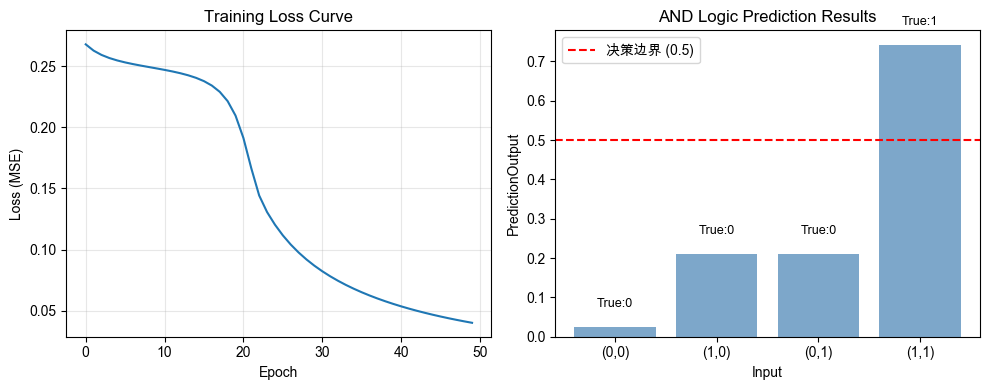


Prediction Results:
  (0, 0) -> 0 (True: 0)
  (1, 0) -> 0 (True: 0)
  (0, 1) -> 0 (True: 0)
  (1, 1) -> 1 (True: 1)


In [5]:
# 可视化Training过程
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)

# TestResult
y_pred_final = neuron.forward(X_and)

plt.subplot(1, 2, 2)
x_test = [f"({X_and[i,0].int().item()},{X_and[i,1].int().item()})" for i in range(4)]
bars = plt.bar(x_test, y_pred_final.flatten().tolist(), color='steelblue', alpha=0.7)
plt.axhline(y=0.5, color='red', linestyle='--', label='决策边界 (0.5)')
plt.xlabel('Input')
plt.ylabel('PredictionOutput')
plt.title('AND Logic Prediction Results')
plt.legend()

# 添加True标签
for i, (bar, true_val) in enumerate(zip(bars, y_and)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'True:{int(true_val.item())}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('training_process.png', dpi=150)
plt.show()

print("\nPrediction Results:")
for i in range(4):
    pred = 1 if y_pred_final[i].item() > 0.5 else 0
    print(f"  ({X_and[i,0].int().item()}, {X_and[i,1].int().item()}) -> {pred} (True: {int(y_and[i].item())})")

---

## 5. 两层网络的反向传播

现在把隐藏层加进来，实现一个完整的 MLP 反向传播：

```
输入 x
  │
  ↓
[Layer1: z1 = x·W1 + b1, a1 = sigmoid(z1)]
  │
  ↓
[Layer2: z2 = a1·W2 + b2, a2 = sigmoid(z2)]
  │
  ↓
损失 L = MSE(a2, y)
```

关键：先从输出层开始，把梯度**反向传播**回去。

In [6]:
class TwoLayerMLP:
    """
    两层 MLP：手动实现反向传播
    """
    def __init__(self, input_size, hidden_size, output_size, learning_rate=5.0):
        self.lr = learning_rate
        
        # 第一层权重
        self.W1 = torch.randn(input_size, hidden_size, requires_grad=True)
        self.b1 = torch.randn(hidden_size, requires_grad=True)
        
        # 第二层权重
        self.W2 = torch.randn(hidden_size, output_size, requires_grad=True)
        self.b2 = torch.randn(output_size, requires_grad=True)
        
        print(f"两层 MLP 创建：{input_size} -> {hidden_size} -> {output_size}")
        
    def forward(self, X):
        """前向传播"""
        # 保存中间值
        self.x = X.clone()
        
        # 第一层
        self.z1 = torch.matmul(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        
        # 第二层
        self.z2 = torch.matmul(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        
        return self.a2
        
    def backward(self, X, y):
        """
        反向传播（手写版）
        """
        n = len(X)
        
        # ===== Output层 =====
        # ∂L/∂a2 = 2 * (a2 - y) / n
        dL_da2 = 2 * (self.a2 - y) / n
        
        # ∂L/∂z2 = ∂L/∂a2 * ∂a2/∂z2 = dL_da2 * sigmoid'(z2)
        dL_dz2 = dL_da2 * sigmoid_derivative(self.z2)
        
        # ∂L/∂W2 = a1.T @ dL_dz2
        dL_dW2 = torch.matmul(self.a1.T, dL_dz2)
        dL_db2 = dL_dz2.sum(dim=0)
        
        # ===== 隐藏层 =====
        # ∂L/∂a1 = dL_dz2 @ W2.T
        dL_da1 = torch.matmul(dL_dz2, self.W2.T)
        
        # ∂L/∂z1 = ∂L/∂a1 * ∂a1/∂z1
        dL_dz1 = dL_da1 * sigmoid_derivative(self.z1)
        
        # ∂L/∂W1 = x.T @ dL_dz1
        dL_dW1 = torch.matmul(self.x.T, dL_dz1)
        dL_db1 = dL_dz1.sum(dim=0)
        
        # ===== 更新权重 =====
        self.W2 = self.W2 - self.lr * dL_dW2
        self.b2 = self.b2 - self.lr * dL_db2
        self.W1 = self.W1 - self.lr * dL_dW1
        self.b1 = self.b1 - self.lr * dL_db1
        
    def train(self, X, y, epochs=100):
        losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = torch.mean((y_pred - y)**2)
            losses.append(loss.item())
            self.backward(X, y)
            
            if (epoch + 1) % 20 == 0:
                print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")
        
        return losses

print()

两层 MLP 创建：2 -> 4 -> 1

Training XOR...
Epoch 20: Loss = 0.2156
Epoch 40: Loss = 0.1804
Epoch 60: Loss = 0.1322
Epoch 80: Loss = 0.0811
Epoch 100: Loss = 0.0474
Epoch 120: Loss = 0.0299
Epoch 140: Loss = 0.0206
Epoch 160: Loss = 0.0153
Epoch 180: Loss = 0.0120
Epoch 200: Loss = 0.0098
Epoch 220: Loss = 0.0082
Epoch 240: Loss = 0.0070
Epoch 260: Loss = 0.0061
Epoch 280: Loss = 0.0054
Epoch 300: Loss = 0.0048
Epoch 320: Loss = 0.0044
Epoch 340: Loss = 0.0040
Epoch 360: Loss = 0.0036
Epoch 380: Loss = 0.0034
Epoch 400: Loss = 0.0031
Epoch 420: Loss = 0.0029
Epoch 440: Loss = 0.0027
Epoch 460: Loss = 0.0026
Epoch 480: Loss = 0.0024
Epoch 500: Loss = 0.0023


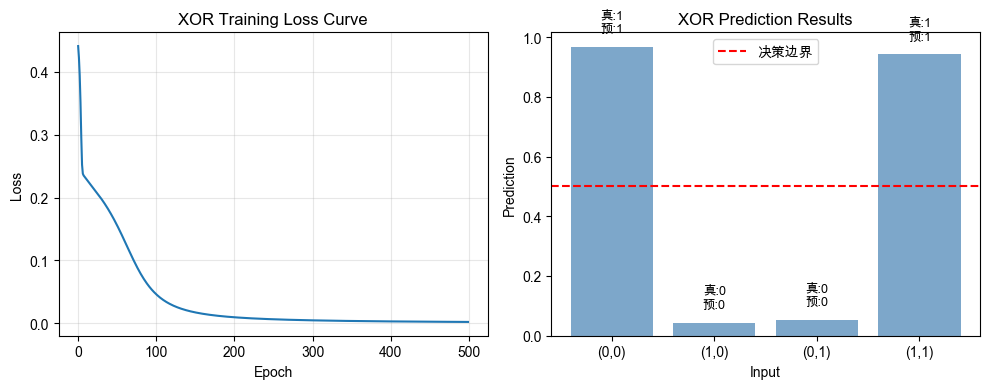


Final Results:
  (0, 0) -> 1 (True: 1) ✓
  (1, 0) -> 0 (True: 0) ✓
  (0, 1) -> 0 (True: 0) ✓
  (1, 1) -> 1 (True: 1) ✓


In [7]:
import numpy as np
# 用两层 MLP 解决 XOR
X_xor = torch.tensor([
    [0.0, 0.0],
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0]
], dtype=torch.float32)
y_xor = torch.tensor([[1.0], [0.0], [0.0], [1.0]], dtype=torch.float32)

mlp = TwoLayerMLP(input_size=2, hidden_size=4, output_size=1, learning_rate=3.0)
print("\nTraining XOR...")
print("="*60)

losses = mlp.train(X_xor, y_xor, epochs=500)

# 可视化
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('XOR Training Loss Curve')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
y_pred = mlp.forward(X_xor)
categories = ['(0,0)', '(1,0)', '(0,1)', '(1,1)']
x_pos = np.arange(len(categories))
bars = plt.bar(x_pos, y_pred.flatten().tolist(), color='steelblue', alpha=0.7)
plt.axhline(y=0.5, color='red', linestyle='--', label='决策边界')
plt.xticks(x_pos, categories)
plt.xlabel('Input')
plt.ylabel('Prediction')
plt.title('XOR Prediction Results')
plt.legend()

for i, (bar, true_val) in enumerate(zip(bars, y_xor)):
    pred_label = 1 if y_pred[i].item() > 0.5 else 0
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'真:{int(true_val.item())}\n预:{pred_label}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nFinal Results:")
for i in range(4):
    pred = 1 if y_pred[i].item() > 0.5 else 0
    true = int(y_xor[i].item())
    status = "✓" if pred == true else "✗"
    print(f"  ({X_xor[i,0].int().item()}, {X_xor[i,1].int().item()}) -> {pred} (True: {true}) {status}")

---

## 今日总结

| 概念 | 含义 |
|------|------|
| 信用分配 | 输出误差该归咎于哪些中间神经元？ |
| 链式法则 | ∂L/∂x = ∂L/∂y × ∂y/∂x |
| 反向传播 | 从输出层到输入层，逐层计算梯度 |
| 梯度下降 | W = W - lr × ∂L/∂W |

**关键流程**：
1. 前向传播：计算预测值
2. 计算损失：L = MSE(pred, y)
3. 反向传播：从后往前，逐层计算 ∂L/∂W
4. 更新权重：往梯度的反方向走

**明天预告**：今天我们手写了反向传播。明天用 PyTorch 的 autograd 简化这个过程，并实现一个完整的 MLP 训练循环。